# 08_understand_panderm_linear_probe_baseline2

This notebook is a **walk-through notebook** for **Baseline 2: Frozen PanDerm + linear probe**.

It mirrors `scripts/eval_panderm_linear_probe.py`, but the goal here is **understanding the full pipeline step by step**.

## What this notebook shows
1. How the official CSV is read and split into train / eval
2. How one image is loaded and transformed
3. How PanDerm Base is built and how the checkpoint is loaded
4. What the important model parts are
5. What tensor shapes look like during one forward pass
6. How frozen image features are extracted
7. How the linear probe is built: `StandardScaler + LogisticRegression`
8. What is actually learned in baseline 2
9. How one eval image is classified
10. How final metrics are computed on the eval split


In [1]:
from pathlib import Path
import json
import random
import sys
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings(
    'ignore',
    message=r'Importing from timm\.models\.layers is deprecated.*',
    category=FutureWarning,
)
warnings.filterwarnings(
    'ignore',
    message=r'Importing from timm\.models\.registry is deprecated.*',
    category=FutureWarning,
)
warnings.filterwarnings(
    'ignore',
    message=r'torch\.meshgrid: in an upcoming release.*',
    category=UserWarning,
)


## Config

Choose either HAM or BCN by changing `CSV_PATH`, `ROOT_PATH`, and `CLASS_NAMES_ARG`.

This notebook expects the same official processed CSV format as used in the script.

In [2]:
REPO_ROOT = Path('..').resolve()
PANDERM_CLASSIFICATION_DIR = (REPO_ROOT / 'external' / 'PanDerm' / 'classification').resolve()
if str(PANDERM_CLASSIFICATION_DIR) not in sys.path:
    sys.path.insert(0, str(PANDERM_CLASSIFICATION_DIR))

from models.builder import get_norm_constants  # type: ignore
from models.modeling_finetune import panderm_base_patch16_224_finetune  # type: ignore

CSV_PATH = REPO_ROOT / 'data' / 'HAM10000' / 'HAM10000.csv'
ROOT_PATH = REPO_ROOT / 'data' / 'HAM10000' / 'images'
CLASS_NAMES_ARG = 'akiec,bcc,bkl,df,mel,nv,vasc'

# CSV_PATH = REPO_ROOT / 'data' / 'BCN20000' / 'bcn20000.csv'
# ROOT_PATH = REPO_ROOT / 'data' / 'BCN20000' / 'images'
# CLASS_NAMES_ARG = 'actinic keratosis,basal cell carcinoma,melanoma,nevus,seborrheic keratosis,solar lentigo,squamous cell carcinoma,dermatofibroma,vascular lesion'

CHECKPOINT_PATH = REPO_ROOT / 'external' / 'weights' / 'panderm_bb_data6_checkpoint-499.pth'

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0
SEED = 42
EVAL_SPLIT = 'test'
MAX_ITER = 1000
C_VALUE = 1.0
CLASS_WEIGHT = 'balanced'   # use 'none' if you want to mirror script option

OUT_DIR = REPO_ROOT / 'outputs' / 'baseline2_understanding'
OUT_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print('DEVICE:', DEVICE)
print('CSV_PATH exists:', CSV_PATH.exists(), CSV_PATH)
print('ROOT_PATH exists:', ROOT_PATH.exists(), ROOT_PATH)
print('CHECKPOINT_PATH exists:', CHECKPOINT_PATH.exists(), CHECKPOINT_PATH)

DEVICE: mps
CSV_PATH exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/HAM10000.csv
ROOT_PATH exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images
CHECKPOINT_PATH exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/external/weights/panderm_bb_data6_checkpoint-499.pth


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print('Seeded with:', SEED)

Seeded with: 42


## Load CSV and inspect splits

In [4]:
df = pd.read_csv(CSV_PATH, low_memory=False)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
display(df.head())

split_series = df['split'].astype(str).str.lower()
train_df = df[split_series == 'train'].copy()
eval_df = df[split_series == EVAL_SPLIT].copy()

print('train_df:', train_df.shape)
print('eval_df:', eval_df.shape)
print('\nTrain label counts:')
print(train_df['label'].value_counts().sort_index())
print('\nEval label counts:')
print(eval_df['label'].value_counts().sort_index())

Shape: (10015, 13)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'split', 'label', 'image', 'binary_label', 'age_group']


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,split,label,image,binary_label,age_group
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0027419.jpg,0,old
1,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0026769.jpg,0,old
2,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0025661.jpg,0,old
3,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0031633.jpg,0,old
4,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0027850.jpg,0,old


train_df: (8207, 13)
eval_df: (1232, 13)

Train label counts:
label
0     273
1     448
2     941
3     102
4    1021
5    5304
6     118
Name: count, dtype: int64

Eval label counts:
label
0     35
1     44
2    107
3      8
4     70
5    951
6     17
Name: count, dtype: int64


## Build class-name mapping

In [5]:
def make_class_name_map(y_train, y_eval, class_names_arg):
    all_ids = sorted(set(y_train.tolist()) | set(y_eval.tolist()))
    if class_names_arg is None:
        return {i: str(i) for i in all_ids}
    names = [x.strip() for x in class_names_arg.split(',')]
    mapping = {}
    for i in all_ids:
        mapping[i] = names[i] if i < len(names) else str(i)
    return mapping

tmp_train_labels = train_df['label'].astype(int).to_numpy()
tmp_eval_labels = eval_df['label'].astype(int).to_numpy()
CLASS_NAME_MAP = make_class_name_map(tmp_train_labels, tmp_eval_labels, CLASS_NAMES_ARG)
display(pd.DataFrame({
    'class_id': list(CLASS_NAME_MAP.keys()),
    'class_name': list(CLASS_NAME_MAP.values())
}))

,class_id,class_name
0,0,akiec
1,1,bcc
2,2,bkl
3,3,df
4,4,mel
5,5,nv
6,6,vasc


## One example image

lesion_id            HAM_0006071
image_id            ISIC_0032343
dx                           bkl
dx_type                    histo
age                         70.0
sex                       female
localization                face
dataset             vidir_modern
split                       test
label                          2
image           ISIC_0032343.jpg
binary_label                   0
age_group                    old
Name: 8783, dtype: object

Example path: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images/ISIC_0032343.jpg
Original PIL size: (600, 450)


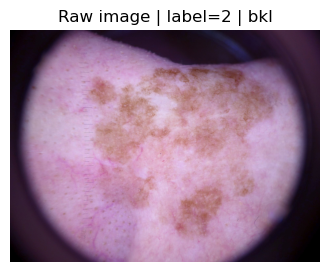

In [6]:
example_row = eval_df.iloc[0].copy()
example_path = ROOT_PATH / str(example_row['image'])
print(example_row)
print('\nExample path:', example_path)

with Image.open(example_path) as img:
    img_rgb = img.convert('RGB')
    print('Original PIL size:', img_rgb.size)
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"Raw image | label={example_row['label']} | {CLASS_NAME_MAP[int(example_row['label'])]}")
    plt.axis('off')
    plt.show()

## Transform used before the model

normalization method:  imagenet
Normalization mean: (0.485, 0.456, 0.406)
Normalization std: (0.228, 0.224, 0.225)
Transformed tensor shape: (3, 224, 224)
Tensor dtype: torch.float32
Tensor min/max: -1.8781511783599854 2.3088455200195312


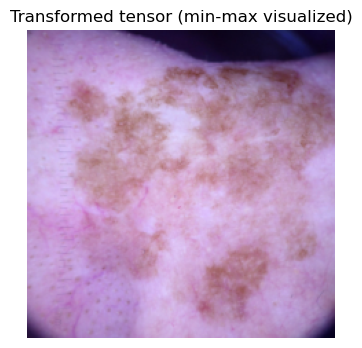

In [7]:
def build_eval_transform(image_size: int):
    mean, std = get_norm_constants('imagenet')
    print('Normalization mean:', mean)
    print('Normalization std:', std)
    return T.Compose([
        T.Resize(256),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])

eval_transform = build_eval_transform(IMAGE_SIZE)
img_tensor = eval_transform(img_rgb)
print('Transformed tensor shape:', tuple(img_tensor.shape))
print('Tensor dtype:', img_tensor.dtype)
print('Tensor min/max:', float(img_tensor.min()), float(img_tensor.max()))

plt.figure(figsize=(4, 4))
vis = img_tensor.permute(1, 2, 0).cpu().numpy()
vis = (vis - vis.min()) / (vis.max() - vis.min() + 1e-8)
plt.imshow(vis)
plt.title('Transformed tensor (min-max visualized)')
plt.axis('off')
plt.show()

## Dataset and dataloader

In [8]:
def safe_open_image(path: Path) -> Image.Image:
    with Image.open(path) as img:
        return img.convert('RGB')

class CSVImageDataset(Dataset):
    def __init__(self, df, root_path: Path, image_col='image', label_col='label', transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.root_path = root_path
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.root_path / str(row[self.image_col])
        img = safe_open_image(image_path)
        img = self.transform(img)
        label = int(row[self.label_col])
        meta = {'image': str(row[self.image_col]), 'label': label}
        return img, label, meta

train_ds = CSVImageDataset(train_df, ROOT_PATH, transform=eval_transform)
eval_ds = CSVImageDataset(eval_df, ROOT_PATH, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
eval_loader = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

one_batch = next(iter(train_loader))
batch_images, batch_labels, batch_meta = one_batch
print('Batch image tensor shape:', tuple(batch_images.shape))
print('Batch labels shape:', tuple(batch_labels.shape))
print('First batch meta example:', {k: batch_meta[k][0] for k in batch_meta})

Batch image tensor shape: (64, 3, 224, 224)
Batch labels shape: (64,)
First batch meta example: {'image': 'ISIC_0027419.jpg', 'label': tensor(2)}


## Build the PanDerm model and load the checkpoint

Important: baseline 2 still uses a **frozen PanDerm encoder**. The learning happens later inside sklearn logistic regression, not inside the ViT backbone.

In [9]:
def build_model(num_classes=1):
    model = panderm_base_patch16_224_finetune(
        pretrained=False,
        num_classes=num_classes,
        drop_rate=0.0,
        drop_path_rate=0.1,
        attn_drop_rate=0.0,
        drop_block_rate=None,
        use_mean_pooling=False,
        init_scale=0.001,
        use_rel_pos_bias=False,
        init_values=1e-5,
        lin_probe=False,
    )
    return model

def load_pretrained_backbone(model, checkpoint_path: Path):
    state_dict = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print('=' * 80)
    print('PanDerm checkpoint loading report')
    print('=' * 80)
    print('Missing keys:', len(missing))
    if missing:
        print('First missing keys:', missing[:20])
    print('Unexpected keys:', len(unexpected))
    if unexpected:
        print('First unexpected keys:', unexpected[:20])

model = build_model(num_classes=1)
load_pretrained_backbone(model, CHECKPOINT_PATH)
model = model.to(DEVICE)
model.eval()

print('\nModel class:', model.__class__.__name__)
print('Has forward_features:', hasattr(model, 'forward_features'))
print('Patch embed module:', type(model.patch_embed).__name__ if hasattr(model, 'patch_embed') else 'N/A')
print('Number of transformer blocks:', len(model.blocks) if hasattr(model, 'blocks') else 'N/A')
print('cls_token shape:', tuple(model.cls_token.shape) if hasattr(model, 'cls_token') else 'N/A')
print('pos_embed shape:', tuple(model.pos_embed.shape) if hasattr(model, 'pos_embed') else 'N/A')
print('head module:', model.head if hasattr(model, 'head') else 'N/A')

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,}')
print(f'Trainable params flag-wise: {trainable_params:,}')
print('Important note: in baseline 2, PanDerm parameters are not updated because we only extract frozen features.')

PanDerm checkpoint loading report
Missing keys: 2
First missing keys: ['head.weight', 'head.bias']
Unexpected keys: 0

Model class: VisionTransformer
Has forward_features: True
Patch embed module: PatchEmbed
Number of transformer blocks: 12
cls_token shape: (1, 1, 768)
pos_embed shape: (1, 197, 768)
head module: Linear(in_features=768, out_features=1, bias=True)
Total params: 85,808,641
Trainable params flag-wise: 85,657,345
Important note: in baseline 2, PanDerm parameters are not updated because we only extract frozen features.


In [10]:
summary_rows = []
if hasattr(model, 'patch_embed'):
    summary_rows.append({'part': 'patch_embed', 'type': type(model.patch_embed).__name__})
summary_rows.append({'part': 'cls_token', 'type': str(tuple(model.cls_token.shape)) if hasattr(model, 'cls_token') else 'N/A'})
summary_rows.append({'part': 'pos_embed', 'type': str(tuple(model.pos_embed.shape)) if hasattr(model, 'pos_embed') else 'N/A'})
summary_rows.append({'part': 'transformer_blocks', 'type': len(model.blocks) if hasattr(model, 'blocks') else 'N/A'})
if hasattr(model, 'norm'):
    summary_rows.append({'part': 'norm', 'type': type(model.norm).__name__})
if hasattr(model, 'fc_norm'):
    summary_rows.append({'part': 'fc_norm', 'type': type(model.fc_norm).__name__})
summary_rows.append({'part': 'head', 'type': type(model.head).__name__ if hasattr(model, 'head') else 'N/A'})
display(pd.DataFrame(summary_rows))

,part,type
0,patch_embed,PatchEmbed
1,cls_token,"(1, 1, 768)"
2,pos_embed,"(1, 197, 768)"
3,transformer_blocks,12
4,norm,LayerNorm
5,fc_norm,NoneType
6,head,Linear


## Forward hooks for temporary shapes

Just like in notebook 07, this is only for inspection.

In [11]:
shape_log = []
hooks = []

def register_shape_hook(module, name):
    def hook(module, inputs, output):
        in_shape = []
        for x in inputs:
            if torch.is_tensor(x):
                in_shape.append(tuple(x.shape))
            elif isinstance(x, (list, tuple)):
                in_shape.append(str(type(x)))
            else:
                in_shape.append(type(x).__name__)

        if torch.is_tensor(output):
            out_shape = tuple(output.shape)
        elif isinstance(output, tuple):
            out_shape = [tuple(o.shape) if torch.is_tensor(o) else type(o).__name__ for o in output]
        else:
            out_shape = type(output).__name__

        shape_log.append({
            'module': name,
            'input_shape': in_shape,
            'output_shape': out_shape
        })
    return module.register_forward_hook(hook)

if getattr(model, 'patch_embed', None) is not None:
    hooks.append(register_shape_hook(model.patch_embed, 'patch_embed'))
if getattr(model, 'blocks', None) is not None and len(model.blocks) > 0:
    hooks.append(register_shape_hook(model.blocks[0], 'block_0'))
    hooks.append(register_shape_hook(model.blocks[-1], 'block_last'))
if getattr(model, 'norm', None) is not None:
    hooks.append(register_shape_hook(model.norm, 'norm'))
if getattr(model, 'head', None) is not None:
    hooks.append(register_shape_hook(model.head, 'head'))

single_x = img_tensor.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    _ = model(single_x)

for h in hooks:
    h.remove()

display(pd.DataFrame(shape_log))

,module,input_shape,output_shape
0,patch_embed,"[(1, 3, 224, 224)]","(1, 196, 768)"
1,block_0,"[(1, 197, 768)]","(1, 197, 768)"
2,block_last,"[(1, 197, 768)]","(1, 197, 768)"
3,norm,"[(1, 197, 768)]","(1, 197, 768)"
4,head,"[(1, 768)]","(1, 1)"


## Important clarification: architecture forward vs baseline-2 feature path

The hook table includes the head because `model(single_x)` runs the full network.

But baseline 2 uses **frozen embeddings**, not the classifier head. The actual decision rule is learned later by sklearn logistic regression.

In [12]:
with torch.no_grad():
    feats_direct = model.forward_features(single_x)
    logits_direct = model(single_x)

print('Output of model.forward_features(single_x):')
print('  shape:', tuple(feats_direct.shape) if torch.is_tensor(feats_direct) else type(feats_direct).__name__)
print('\nOutput of model(single_x):')
print('  shape:', tuple(logits_direct.shape) if torch.is_tensor(logits_direct) else type(logits_direct).__name__)

print('\nInterpretation:')
print('- Baseline 2 uses the embedding from forward_features().')
print('- The final classification is done by sklearn logistic regression on top of those frozen embeddings.')
print('- So the PanDerm head is not the learned decision rule in baseline 2.')

Output of model.forward_features(single_x):
  shape: (1, 768)

Output of model(single_x):
  shape: (1, 1)

Interpretation:
- Baseline 2 uses the embedding from forward_features().
- The final classification is done by sklearn logistic regression on top of those frozen embeddings.
- So the PanDerm head is not the learned decision rule in baseline 2.


## Feature extraction logic
This mirrors the script exactly.

In [13]:
@torch.no_grad()
def extract_features_debug(model, images: torch.Tensor):
    debug = {}

    if hasattr(model, 'forward_features'):
        feats = model.forward_features(images)
        debug['used_forward_features'] = True
    else:
        feats = model(images)
        debug['used_forward_features'] = False

    debug['raw_output_type'] = type(feats).__name__
    if torch.is_tensor(feats):
        debug['raw_output_shape'] = tuple(feats.shape)
    elif isinstance(feats, tuple):
        debug['raw_output_shape'] = [tuple(x.shape) if torch.is_tensor(x) else type(x).__name__ for x in feats]

    if isinstance(feats, tuple):
        feats = feats[0]
        debug['tuple_reduced_to_first'] = True
    else:
        debug['tuple_reduced_to_first'] = False

    if feats.ndim == 3:
        debug['token_sequence_shape'] = tuple(feats.shape)
        if feats.shape[1] > 1:
            feats = feats[:, 0]
            debug['cls_taken'] = True
            debug['after_cls_shape'] = tuple(feats.shape)
        else:
            feats = feats.mean(dim=1)
            debug['mean_pooled_single_token_sequence'] = True

    if feats.ndim > 2:
        feats = feats.flatten(start_dim=1)
        debug['flattened'] = True
        debug['after_flatten_shape'] = tuple(feats.shape)
    else:
        debug['flattened'] = False

    feats_before_norm = feats.clone()
    feats = F.normalize(feats, dim=1)
    debug['final_feature_shape'] = tuple(feats.shape)
    debug['norm_before'] = torch.norm(feats_before_norm, dim=1).cpu().numpy().tolist()
    debug['norm_after'] = torch.norm(feats, dim=1).cpu().numpy().tolist()
    return feats, debug

single_feat, single_debug = extract_features_debug(model, single_x)
print(json.dumps(single_debug, indent=2))

{
  "used_forward_features": true,
  "raw_output_type": "Tensor",
  "raw_output_shape": [
    1,
    768
  ],
  "tuple_reduced_to_first": false,
  "flattened": false,
  "final_feature_shape": [
    1,
    768
  ],
  "norm_before": [
    15.424509048461914
  ],
  "norm_after": [
    0.9999999403953552
  ]
}


## Collect train and eval features

In [14]:
@torch.no_grad()
def collect_features(model, loader, device):
    model.eval()
    all_feats = []
    all_labels = []
    all_meta = []

    for images, labels, meta in tqdm(loader, desc='extract_features', leave=False):
        images = images.to(device, non_blocking=(device == 'cuda'))
        feats, _ = extract_features_debug(model, images)
        all_feats.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())
        all_meta.extend([{k: meta[k][i] for k in meta} for i in range(len(labels))])

    feats_np = np.concatenate(all_feats, axis=0)
    labels_np = np.concatenate(all_labels, axis=0)
    return feats_np, labels_np, all_meta

train_feats, train_labels, train_meta = collect_features(model, train_loader, DEVICE)
eval_feats, eval_labels, eval_meta = collect_features(model, eval_loader, DEVICE)

print('train_feats shape:', train_feats.shape)
print('eval_feats shape:', eval_feats.shape)
print('Feature dimension:', train_feats.shape[1])

extract_features:   0%|          | 0/129 [00:00<?, ?it/s]

extract_features:   0%|          | 0/20 [00:00<?, ?it/s]

train_feats shape: (8207, 768)
eval_feats shape: (1232, 768)
Feature dimension: 768


## What is learned in baseline 2?

Here is the key conceptual difference from baseline 1:

- **PanDerm backbone:** frozen, only used as feature extractor
- **StandardScaler:** fitted on train features
- **LogisticRegression:** fitted on train features and train labels

So the learning happens only in the linear classifier.

In [15]:
print('Is PanDerm updated during baseline 2? -> No')
print('Is there torch optimizer / loss.backward() on PanDerm? -> No')
print('What is fitted? -> StandardScaler + LogisticRegression')
print('Where does learning happen? -> In sklearn logistic regression coefficients and intercept')

Is PanDerm updated during baseline 2? -> No
Is there torch optimizer / loss.backward() on PanDerm? -> No
What is fitted? -> StandardScaler + LogisticRegression
Where does learning happen? -> In sklearn logistic regression coefficients and intercept


## Fit the linear probe

In [16]:
probe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=MAX_ITER,
        C=C_VALUE,
        class_weight=None if CLASS_WEIGHT == 'none' else CLASS_WEIGHT,
        solver='lbfgs',
        random_state=SEED,
    ))
])

probe.fit(train_feats, train_labels)
print('Linear probe fitted.')
print('Pipeline steps:', probe.named_steps.keys())

Linear probe fitted.
Pipeline steps: dict_keys(['scaler', 'clf'])


In [17]:
scaler = probe.named_steps['scaler']
clf = probe.named_steps['clf']

print('Scaler mean shape:', scaler.mean_.shape)
print('Scaler scale shape:', scaler.scale_.shape)
print('Classifier coef shape:', clf.coef_.shape)
print('Classifier intercept shape:', clf.intercept_.shape)
print('Classifier classes_:', clf.classes_)

coef_df = pd.DataFrame({
    'class_id': clf.classes_,
    'class_name': [CLASS_NAME_MAP[int(x)] for x in clf.classes_],
    'coef_l2_norm': [float(np.linalg.norm(w)) for w in clf.coef_],
    'intercept': clf.intercept_.tolist(),
})
display(coef_df)

Scaler mean shape: (768,)
Scaler scale shape: (768,)
Classifier coef shape: (7, 768)
Classifier intercept shape: (7,)
Classifier classes_: [0 1 2 3 4 5 6]


,class_id,class_name,coef_l2_norm,intercept
0,0,akiec,10.168090,-4.624975
1,1,bcc,10.113803,-5.170364
2,2,bkl,11.467130,4.243105
3,3,df,6.998408,-5.038912
4,4,mel,10.410959,5.870644
5,5,nv,9.431733,9.421487
6,6,vasc,4.070086,-4.700985


## Understand one example prediction in detail

In [18]:
example_eval_idx = 0
example_meta = eval_meta[example_eval_idx]
x_raw = eval_feats[example_eval_idx:example_eval_idx+1]

# Manual scaled version
x_scaled = scaler.transform(x_raw)

# Class scores from the logistic-regression classifier itself
logits_like = clf.decision_function(x_scaled)

# Full pipeline prediction (scaler + classifier)
probs = probe.predict_proba(x_raw)
pred = probe.predict(x_raw)

print('Example meta:', example_meta)
print('Raw feature shape:', x_raw.shape)
print('Scaled feature shape:', x_scaled.shape)
print('Decision-function shape:', np.array(logits_like).shape)
print('Probability shape:', probs.shape)
print('Predicted class id:', int(pred[0]))
print('Predicted class name:', CLASS_NAME_MAP[int(pred[0])])

print('\nInterpretation:')
print('- x_raw is the frozen PanDerm embedding.')
print('- scaler.transform(x_raw) standardizes that embedding.')
print('- clf.decision_function(x_scaled) gives class scores after scaling.')
print('- probe.predict_proba(x_raw) runs the full pipeline: scaler first, then logistic regression.')
print('- Baseline 2 predicts with the sklearn pipeline, not with the PanDerm head.')

Example meta: {'image': 'ISIC_0032343.jpg', 'label': tensor(2)}
Raw feature shape: (1, 768)
Scaled feature shape: (1, 768)
Decision-function shape: (1, 7)
Probability shape: (1, 7)
Predicted class id: 2
Predicted class name: bkl

Interpretation:
- x_raw is the frozen PanDerm embedding.
- scaler.transform(x_raw) standardizes that embedding.
- clf.decision_function(x_scaled) gives class scores after scaling.
- probe.predict_proba(x_raw) runs the full pipeline: scaler first, then logistic regression.
- Baseline 2 predicts with the sklearn pipeline, not with the PanDerm head.


,class_id,class_name,probability
0,2,bkl,9.999483e-01
1,5,nv,2.883021e-05
2,4,mel,2.235445e-05
3,0,akiec,5.080800e-07
4,3,df,3.976628e-08
5,6,vasc,8.498084e-11
6,1,bcc,9.392445e-13


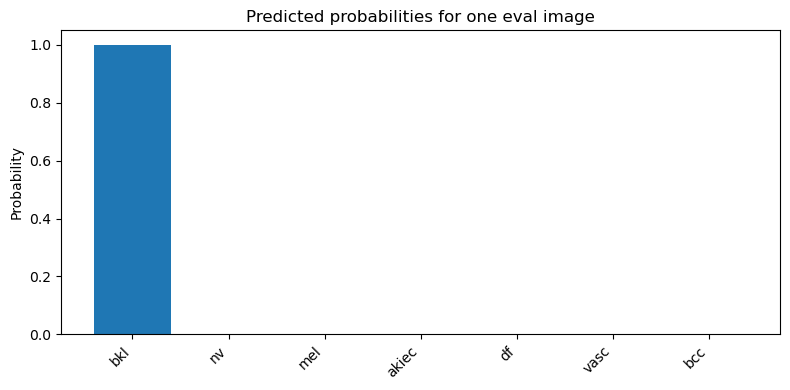

In [19]:
class_ids = list(clf.classes_)
detail_df = pd.DataFrame({
    'class_id': class_ids,
    'class_name': [CLASS_NAME_MAP[int(c)] for c in class_ids],
    'probability': probs[0],
})
detail_df = detail_df.sort_values('probability', ascending=False).reset_index(drop=True)
display(detail_df)

plt.figure(figsize=(8, 4))
plt.bar(detail_df['class_name'], detail_df['probability'])
plt.xticks(rotation=45, ha='right')
plt.title('Predicted probabilities for one eval image')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()

## Full eval prediction

In [20]:
preds = probe.predict(eval_feats)
pred_probs = probe.predict_proba(eval_feats)
y_true = eval_labels

## Metrics

In [21]:
label_ids = sorted(CLASS_NAME_MAP.keys())
target_names = [CLASS_NAME_MAP[i] for i in label_ids]
cm = confusion_matrix(y_true, preds, labels=label_ids)
per_class_recall_values = recall_score(y_true, preds, labels=label_ids, average=None, zero_division=0)

metrics = {
    'accuracy': float(accuracy_score(y_true, preds)),
    'balanced_accuracy': float(balanced_accuracy_score(y_true, preds)),
    'macro_f1': float(f1_score(y_true, preds, average='macro', zero_division=0)),
    'mcc': float(matthews_corrcoef(y_true, preds)),
    'per_class_recall': {
        CLASS_NAME_MAP[label_id]: float(per_class_recall_values[idx])
        for idx, label_id in enumerate(label_ids)
    },
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report(
        y_true,
        preds,
        labels=label_ids,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    ),
}

print(json.dumps({
    'accuracy': metrics['accuracy'],
    'balanced_accuracy': metrics['balanced_accuracy'],
    'macro_f1': metrics['macro_f1'],
    'mcc': metrics['mcc'],
    'per_class_recall': metrics['per_class_recall'],
}, indent=2))

{
  "accuracy": 0.8863636363636364,
  "balanced_accuracy": 0.7786976158052852,
  "macro_f1": 0.7144017922649618,
  "mcc": 0.7330216303507753,
  "per_class_recall": {
    "akiec": 0.7142857142857143,
    "bcc": 0.7727272727272727,
    "bkl": 0.7570093457943925,
    "df": 0.75,
    "mel": 0.6428571428571429,
    "nv": 0.9316508937960042,
    "vasc": 0.8823529411764706
  }
}


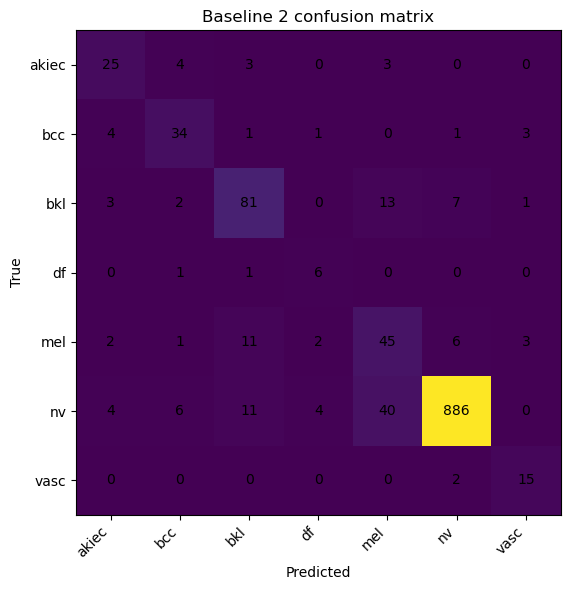

In [22]:
cm_arr = np.array(metrics['confusion_matrix'])
plt.figure(figsize=(7, 6))
plt.imshow(cm_arr)
plt.title('Baseline 2 confusion matrix')
plt.xticks(range(len(target_names)), target_names, rotation=45, ha='right')
plt.yticks(range(len(target_names)), target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm_arr.shape[0]):
    for j in range(cm_arr.shape[1]):
        plt.text(j, i, str(cm_arr[i, j]), ha='center', va='center')
plt.tight_layout()
plt.show()

## Prediction table for inspection

In [23]:
pred_df = pd.DataFrame(eval_meta)

# Make label column clean integers if it came through as tensors
if 'label' in pred_df.columns:
    pred_df['label'] = pred_df['label'].apply(
        lambda x: int(x.item()) if torch.is_tensor(x) else int(x)
    )

pred_df['y_true'] = y_true
pred_df['y_pred'] = preds
pred_df['y_true_name'] = [CLASS_NAME_MAP[int(x)] for x in y_true]
pred_df['y_pred_name'] = [CLASS_NAME_MAP[int(x)] for x in preds]
pred_df['correct'] = pred_df['y_true'] == pred_df['y_pred']

for i, cls_id in enumerate(clf.classes_):
    pred_df[f"prob_{CLASS_NAME_MAP[int(cls_id)]}"] = pred_probs[:, i]

display(pred_df.head())

,image,label,y_true,y_pred,y_true_name,y_pred_name,correct,prob_akiec,prob_bcc,prob_bkl,prob_df,prob_mel,prob_nv,prob_vasc
0,ISIC_0032343.jpg,2,2,2,bkl,bkl,True,5.080800e-07,9.392445e-13,0.999948,3.976628e-08,2.235445e-05,0.000029,8.498084e-11
1,ISIC_0024698.jpg,5,5,5,nv,nv,True,2.369748e-08,5.435738e-09,0.022045,1.110122e-07,2.948829e-01,0.683072,7.154048e-09
2,ISIC_0031624.jpg,2,2,2,bkl,bkl,True,4.788294e-09,3.759328e-08,0.987726,8.313758e-11,1.574802e-03,0.010699,8.262139e-09
3,ISIC_0025510.jpg,2,2,2,bkl,bkl,True,2.940044e-11,1.052799e-08,0.971826,6.160927e-05,1.167119e-02,0.016441,7.265551e-08
4,ISIC_0025388.jpg,2,2,2,bkl,bkl,True,3.512956e-15,1.304950e-14,0.999958,3.079641e-16,2.489172e-08,0.000042,9.547747e-13


## Save a debug summary JSON
Useful later for Mermaid flowchart design.

In [24]:
# debug_summary = {
#     'baseline_name': 'Frozen PanDerm + linear probe',
#     'csv_path': str(CSV_PATH),
#     'root_path': str(ROOT_PATH),
#     'checkpoint_path': str(CHECKPOINT_PATH),
#     'device': DEVICE,
#     'train_rows': int(len(train_df)),
#     'eval_rows': int(len(eval_df)),
#     'train_feature_shape': list(train_feats.shape),
#     'eval_feature_shape': list(eval_feats.shape),
#     'feature_dim': int(train_feats.shape[1]),
#     'classifier_coef_shape': list(clf.coef_.shape),
#     'classifier_intercept_shape': list(clf.intercept_.shape),
#     'single_image_feature_debug': single_debug,
#     'metrics': {
#         'accuracy': metrics['accuracy'],
#         'balanced_accuracy': metrics['balanced_accuracy'],
#         'macro_f1': metrics['macro_f1'],
#         'mcc': metrics['mcc'],
#     },
#     'key_takeaway': 'PanDerm is frozen. The only learned part is the sklearn logistic regression classifier trained on extracted train embeddings.'
# }
# debug_json_path = OUT_DIR / 'baseline2_debug_summary.json'
# with open(debug_json_path, 'w', encoding='utf-8') as f:
#     json.dump(debug_summary, f, indent=2)
# print('Saved debug summary to:', debug_json_path)

## Mermaid-ready textual summary

### Actual Baseline 2 pipeline
1. Raw image
2. Resize to 256
3. Center crop to 224
4. Convert to tensor
5. Normalize with ImageNet mean/std
6. Pass through **frozen PanDerm encoder**
7. Use `forward_features()` to obtain embedding
8. Convert embedding to final feature vector
9. L2-normalize feature vector
10. Extract train embeddings for all train images
11. Fit `StandardScaler` on train embeddings
12. Fit `LogisticRegression` on scaled train embeddings + train labels
13. Extract eval embeddings
14. Apply scaler to eval embeddings
15. Predict class probabilities with logistic regression
16. Argmax probability -> final predicted class

### Important note
The PanDerm backbone is frozen. The learned decision rule comes from the sklearn linear classifier, not from the PanDerm head.

In [25]:
print('MERMAID SUMMARY')
print('- Raw image')
print('- Transform: resize 256 -> center crop 224 -> tensor -> normalize')
print('- Frozen PanDerm Base encoder')
print('- Use forward_features() to obtain embedding')
print('- Convert embedding to final feature vector')
print('- L2 normalization')
print('- Extract train embeddings')
print('- Fit StandardScaler on train embeddings')
print('- Fit LogisticRegression on scaled train embeddings and labels')
print('- Extract eval embeddings')
print('- Scale eval embeddings with fitted scaler')
print('- Predict class probabilities with logistic regression')
print('- Argmax probability -> final predicted class')
print('- PanDerm is frozen throughout')
print('- No torch optimizer, no loss.backward(), no backbone weight update')

MERMAID SUMMARY
- Raw image
- Transform: resize 256 -> center crop 224 -> tensor -> normalize
- Frozen PanDerm Base encoder
- Use forward_features() to obtain embedding
- Convert embedding to final feature vector
- L2 normalization
- Extract train embeddings
- Fit StandardScaler on train embeddings
- Fit LogisticRegression on scaled train embeddings and labels
- Extract eval embeddings
- Scale eval embeddings with fitted scaler
- Predict class probabilities with logistic regression
- Argmax probability -> final predicted class
- PanDerm is frozen throughout
- No torch optimizer, no loss.backward(), no backbone weight update
